In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /n/home13/wcarvalho/projects/preplay-human/analysis_notebooks
changing to root directory
at directory: /n/home13/wcarvalho/projects/preplay-human


In [12]:
import glob
print("at directory:", os.getcwd())

glob.glob('keys/*')

at directory: /n/home13/wcarvalho/projects/preplay-human


['keys/datastore-key.json']

In [4]:
# ON SERVER
RESULTS_DIR ='/n/holylfs06/LABS/kempner_fellow_wcarvalho'
USER_RESULTS_DIR = os.path.join(RESULTS_DIR, 'results/human_dyna_craftax/user_data/exps')

In [ ]:
# # ON COMPUTER
# RESULTS_DIR ='/Users/wilka/git/research/'
# USER_RESULTS_DIR = os.path.join(RESULTS_DIR, 'results/human_dyna_craftax/user_data/exps')

In [13]:
from analysis.craftax_download_data import download_user_files
import craftax_experiment_configs as config

bucket_name = config.BUCKET_NAME  # google cloud
bucket_prefix = "data/"
# pattern = "data/data_user=*_name=r0-v2*debug=0.json"
human_data_pattern = "data/*v1*debug=0.json"
# human_data_pattern = "data/*4220*.json"


download_user_files(
    bucket_name=bucket_name,
    prefix=bucket_prefix,
    pattern=human_data_pattern,
    destination_folder=USER_RESULTS_DIR)

Downloaded: data/user=1284548673_worker=A161QJEUXJ2OU_name=craftax_v1-paths-r1-m1_debug=0.json to /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1284548673_worker=A161QJEUXJ2OU_name=craftax_v1-paths-r1-m1_debug=0.json
Downloaded: data/user=1565967854_worker=AKSJ3C5O3V9RB_name=craftax_v1-paths-r1-m1_debug=0.json to /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1565967854_worker=AKSJ3C5O3V9RB_name=craftax_v1-paths-r1-m1_debug=0.json
Downloaded: data/user=1772965635_worker=A36CQIFWEDEECU_name=craftax_v1-juncture-r1-m0_debug=0.json to /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1772965635_worker=A36CQIFWEDEECU_name=craftax_v1-juncture-r1-m0_debug=0.json
Downloaded: data/user=180830831_worker=A6KOTWP7N7RLU_name=craftax_v1-juncture-r0-m0_debug=0.json to /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=180830831_worker=A6

# Get files

In [15]:
from glob import glob

files = f"{USER_RESULTS_DIR}/*v1*.json"
valid_files = list(set(glob(files)))
len(valid_files)

35

In [16]:
from pprint import pprint
import json
from nicewebrl.utils import read_all_records

nfinished = 0
for idx, file in enumerate(valid_files):
  try:
    data = await read_all_records(file)
  except Exception as e:
    print("-" * 25)
    print(idx, os.path.basename(file))
    print(e)
    continue
  if not len(data):
    continue
  finished = data[-1].get("finished", False)
  if finished:
    print
    nfinished += 1
    print("-" * 25)
    print(idx, os.path.basename(file))
    print("\n" + data[-1]["feedback"] or "N/A")
    # print('bonus:', data[-1]['bonus'])
    print("feedback:")
    if "feedback" in data[-2]["data"]:
      pprint(data[-2]["data"])

-------------------------
0 user=4220120544_name=craftax_v1-paths-r1-m0_debug=0.json


feedback:
-------------------------
1 user=1284548673_worker=A161QJEUXJ2OU_name=craftax_v1-paths-r1-m1_debug=0.json

None
feedback:
-------------------------
2 user=2907764405_worker=AZ69TBTDH7AZS_name=craftax_v1-paths-r0-m1_debug=0.json


feedback:
-------------------------
3 user=4172656471_worker=A1WYDO7PQJ8UG_name=craftax_v1-paths-r0-m1_debug=0.json

There was some input lag between when I would press an arrow and when my little guy would move. Also it was somewhat unclear which spaces were traversible and which were obstacles, but I imagine the lack of clarity in that was part of the experiment. 
feedback:
-------------------------
4 user=2085357097_worker=A3UV55HC87DO9C_name=craftax_v1-juncture-r0-m0_debug=0.json

I feel like the UI was a little glitchy. Like I had to figure out the quirks. It seemed like having the cursor inside the playing area would sometimes toggle or un-toggle fullscreen i

Failed to unpack record in /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=4009362118_worker=A1CN1H9UODZ1E6_name=craftax_v1-paths-r1-m1_debug=0.json: unpack(b) received extra data.


-------------------------
23 user=3899648988_worker=AEOFJWOEXF94U_name=craftax_v1-paths-r0-m0_debug=0.json

it was fine 
feedback:
-------------------------
24 user=464290574_worker=A3N0QZ9ZKUCTCQ_name=craftax_v1-paths-r1-m1_debug=0.json


feedback:
-------------------------
25 user=3845734957_worker=A2KDYSLV030FVX_name=craftax_v1-juncture-r0-m0_debug=0.json

The page would not load to the next phase unless I would close and reenter the page.
feedback:
-------------------------
26 user=1933467664_worker=A193SP8INHA4MB_name=craftax_v1-paths-r0-m0_debug=0.json

Everything went fine. It was fun!
feedback:
-------------------------
27 user=2878499878_worker=A1CTM8W6WOP9Z6_name=craftax_v1-paths-r0-m1_debug=0.json

NONE
feedback:
-------------------------
28 user=3820052190_worker=A1BWS5AD2T4NIR_name=craftax_v1-paths-r1-m0_debug=0.json

Nothing went wrong except for me accidentally pressing space when focused on the "leave fullscreen button" once. The experiment would be easier if it didn't 

In [18]:
(
  data[0]["data"].keys(),
  data[-2]["data"].keys(),
  data[-2]["metadata"].keys(),
  data[-1].keys(),
)

(dict_keys(['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']),
 dict_keys(['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']),
 dict_keys(['world_seed', 'condition', 'eval', 'block_metadata', 'type', 'nsteps', 'nepisodes', 'nsuccesses']),
 dict_keys(['finished', 'feedback', 'user_storage']))

In [19]:
data[-2]["metadata"]

{'world_seed': 3,
 'condition': 1,
 'eval': True,
 'block_metadata': {'manipulation': 'paths',
  'desc': 'reusing longer of two paths which matches training path',
  'long': 'Here there are two paths to the test object. We predict that people will take the path that was used to get to the training object.',
  'name': 'paths_0',
  'world_seed': 3,
  'start_train_positions': [[32, 30], [17, 28], [29, 15]],
  'start_eval_positions': [[28, 25]],
  'train_objects': [21, 22],
  'test_objects': [10],
  'start_eval2_positions': None,
  'train_object_location': [39, 44],
  'test_object_location': [39, 46],
  'train_distractor_object_location': [35, 13]},
 'type': 'EnvStage',
 'nsteps': 227,
 'nepisodes': 1,
 'nsuccesses': 1}

In [20]:
data[-1]["user_storage"]

{'seed': 4220120544,
 'rng_splits': 3058,
 'rng_key': [4129114439, 1312439276],
 'init_rng_key': [0, 4220120544],
 'session_start': '2025-02-07T17:43:22.448414',
 'session_duration': 41.758381766666666,
 'worker_id': None,
 'hit_id': None,
 'assignment_id': None,
 'user_id': 4220120544,
 'stage_idx': 21,
 'block_idx': 6,
 'user_info': {'worker_id': None,
  'hit_id': None,
  'assignment_id': None,
  'git_version': 'git_version_unknown'},
 'env_vars': {'EVAL_SHOW_MAP': '0',
  'FLY_ALLOC_ID': '2866220c799ed8',
  'FLY_APP_NAME': 'human-dyna-craftax-v1-paths-r1-m0',
  'FLY_IMAGE_REF': 'registry.fly.io/human-dyna-craftax-v1-paths-r1-m0:deployment-01JKGPZCAX6M9T3XY4SZCZXA5D',
  'FLY_MACHINE_ID': '2866220c799ed8',
  'FLY_MACHINE_VERSION': '01JKGQ3D2FC1Y09GX2T2MPMMGA',
  'FLY_PRIVATE_IP': 'fdaa:9:cf9b:a7b:12:7d82:f767:2',
  'FLY_PROCESS_GROUP': 'app',
  'FLY_PUBLIC_IP': '2605:4c40:230:b71e:0:7d82:f767:1',
  'FLY_REGION': 'bos',
  'FLY_VM_MEMORY_MB': '32768',
  'GIVE_INSTRUCTIONS': '1',
  'GPG_K

In [17]:
import jax
import craftax_experiment_structure as experiment

example_timestep = experiment.jax_web_env.reset(
  jax.random.PRNGKey(0), experiment.dummy_params
)

Compiling environment reset and step functions.
	reset time: 24.9593346118927
	step time: 27.388311862945557
Compiling multi-render function.
	time: 5.378906488418579


In [18]:
from analysis import craftax_user_data
import nicewebrl

In [ ]:
# %debug
file = '/n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=2085357097_worker=A3UV55HC87DO9C_name=craftax_v1-juncture-r0-m0_debug=0.json'
# file = valid_files[0]
file, episode_df, episode_data = await craftax_user_data.make_episode_data(
  file=file,
  example_timestep=example_timestep,
  debug=True,
    overwrite_episode_info=True,
)
if episode_df is not None and episode_data is not None:
    df = nicewebrl.DataFrame(episode_df, episode_data)

In [ ]:
if episode_df is not None and episode_data is not None:
    %debug
    df = nicewebrl.DataFrame(df, episode_data)

In [32]:
type(episode_df), type(episode_data)

(polars.dataframe.frame.DataFrame, list)

In [12]:
df.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,exp_name,tell_reuse,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,i64,i64,str,str,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
0,15,0,"""paths_1_training""","""reusing longer of two paths wh…","""paths""",0,1,false,22,0,4220120544,31,"""Male""","""craftax_v1-paths-r1-m0""",1,0,1,1,1.0,50,1.0,0.629147,-0.608226,-30.41132,-0.633479,1.8705722,1.8705722,1.8705722,0.08802,0.3994538,49
1,15,0,"""paths_1_training""","""reusing longer of two paths wh…","""paths""",1,2,false,22,0,4220120544,31,"""Male""","""craftax_v1-paths-r1-m0""",1,0,1,1,1.0,55,1.0,0.6528511,-0.8128,-44.703983,-0.839941,1.2817696,1.2817696,1.2817696,-0.28235,0.5282784,54
2,15,0,"""paths_1_training""","""reusing longer of two paths wh…","""paths""",2,3,false,10,1,4220120544,31,"""Male""","""craftax_v1-paths-r1-m0""",1,0,1,1,0.0,18,1.0,1.0306939,-0.80446,-14.480283,-0.91241,1.0306939,0.3096955,0.3096955,-0.759266,-0.759266,17


In [13]:
import craftax_utils

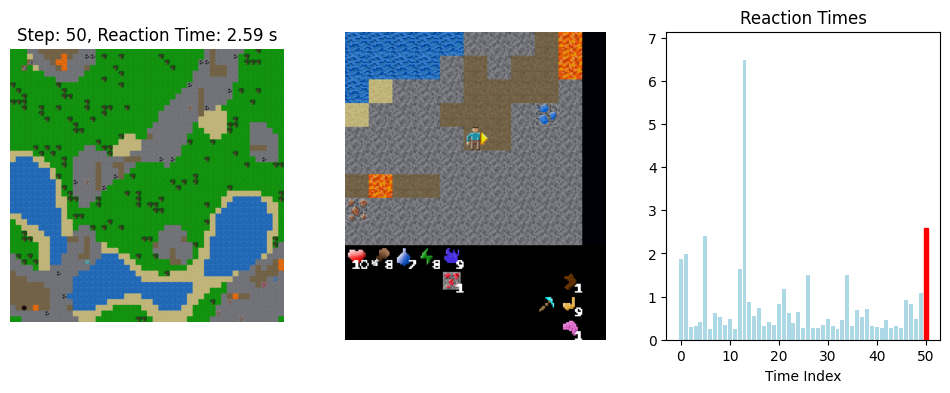

In [14]:
new = df.filter(eval=False)
new.head()
craftax_utils.create_episode_reaction_times_video(new.episodes[0])